In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from scipy.stats import ttest_ind
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings, os
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
SEED = 42
print('All libraries loaded.')

All libraries loaded.


### QUESTION 1   DATA ACQUISITION, JOINING & CLEANING
## [30 Marks]


# The FinSight Bank dataset is distributed across nine CSV files linked by a common loan_id key. Your first task is to assemble and clean the full dataset before any analysis can begin.

# (a)
# Load all nine CSV files using pd.read_csv(). For files exceeding available RAM, use chunksize appropriately. Save the concatenated output as a Parquet file and report: (i) memory usage before and after downcasting, and (ii) file size of the resulting Parquet.
# (5)



In [5]:
DATA_DIR = ''   # ← Change to your folder containing the 9 CSV files

files = {
    'loans_master':          'loans_master.csv',
    'loan_performance':      'loan_performance.csv',
    'customer_bureau':       'customer_bureau.csv',
    'branch_region_economy': 'branch_region_economy.csv',
    'collateral_assets':     'collateral_assets.csv',
    'credit_card_behavior':  'credit_card_behavior.csv',
    'loan_enquiry_bureau':   'loan_enquiry_bureau.csv',
    'monthly_emi_track':     'monthly_emi_track.csv',
    'payment_history':       'payment_history.csv',
}

dfs = {}
for name, fname in files.items():
    path = os.path.join(DATA_DIR, fname)
    # Use chunksize for large files to manage RAM
    chunks = []
    for chunk in pd.read_csv(path, chunksize=500_000):
        chunks.append(chunk)
    dfs[name] = pd.concat(chunks, ignore_index=True)
    print(f'{name}: {dfs[name].shape}')

loans_master: (2000000, 27)
loan_performance: (2000000, 12)
customer_bureau: (2000000, 30)
branch_region_economy: (2000000, 19)
collateral_assets: (2000000, 20)
credit_card_behavior: (2000000, 17)
loan_enquiry_bureau: (2000000, 24)
monthly_emi_track: (2000000, 23)
payment_history: (2000000, 18)


In [6]:
# Memory before downcast (use loans_master as representative)
df_raw = dfs['loans_master'].copy()
mem_before = df_raw.memory_usage(deep=True).sum() / 1e6
print(f'Memory BEFORE downcast: {mem_before:.1f} MB')

def downcast_df(df):
    """Downcast numeric columns to reduce memory usage."""
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

df_raw = downcast_df(df_raw)
mem_after = df_raw.memory_usage(deep=True).sum() / 1e6
print(f'Memory AFTER  downcast: {mem_after:.1f} MB')
print(f'Reduction: {(1 - mem_after/mem_before)*100:.1f}%')

# Save as Parquet
df_raw.to_parquet('loans_master.parquet', index=False)
parquet_size = os.path.getsize('loans_master.parquet') / 1e6
print(f'Parquet file size: {parquet_size:.2f} MB')

Memory BEFORE downcast: 1640.7 MB
Memory AFTER  downcast: 1520.7 MB
Reduction: 7.3%
Parquet file size: 67.32 MB


# Question 1 b

In [8]:
# Start with the master table
df = dfs['loans_master'].copy()
N = 2_000_000

tables_to_join = [
    'payment_history',
    'customer_bureau',
    'loan_performance',
    'branch_region_economy',
    'collateral_assets',
    'credit_card_behavior',
    'loan_enquiry_bureau',
    'monthly_emi_track',
]

orphan_report = []

for tbl in tables_to_join:
    right = dfs[tbl]
    # Check orphan records: rows in right NOT in left
    orphans = right[~right['loan_id'].isin(df['loan_id'])].shape[0]
    orphan_report.append({'table': tbl, 'orphan_records': orphans})
    
    # Drop duplicate columns from right (except loan_id)
    overlap = [c for c in right.columns if c in df.columns and c != 'loan_id']
    right = right.drop(columns=overlap)
    
    df = df.merge(right, on='loan_id', how='left')
    assert df.shape[0] == N, f'Row count mismatch after joining {tbl}: {df.shape[0]}'
    print(f'After joining {tbl}: {df.shape[0]:,} rows, {df.shape[1]} cols ')

print('\nOrphan Record Report:')
print(pd.DataFrame(orphan_report).to_string(index=False))



After joining payment_history: 2,000,000 rows, 44 cols 
After joining customer_bureau: 2,000,000 rows, 73 cols 
After joining loan_performance: 2,000,000 rows, 84 cols 
After joining branch_region_economy: 2,000,000 rows, 102 cols 
After joining collateral_assets: 2,000,000 rows, 121 cols 
After joining credit_card_behavior: 2,000,000 rows, 137 cols 
After joining loan_enquiry_bureau: 2,000,000 rows, 160 cols 
After joining monthly_emi_track: 2,000,000 rows, 182 cols 

Orphan Record Report:
                table  orphan_records
      payment_history               0
      customer_bureau               0
     loan_performance               0
branch_region_economy               0
    collateral_assets               0
 credit_card_behavior               0
  loan_enquiry_bureau               0
    monthly_emi_track               0


# Question 1 c

# Initialise dirty flag
df['dirty_flag'] = 0

issues = []

# Issue 1: Negative loan amounts
mask1 = df['loan_amnt_inr'] < 0
issues.append({'Issue': '1', 'Column': 'loan_amnt_inr', 'Count': mask1.sum(),
               'Why Invalid': 'Loan amount cannot be negative',
               'Strategy': 'Absolute value (flip sign)'})
df.loc[mask1, 'loan_amnt_inr'] = df.loc[mask1, 'loan_amnt_inr'].abs()
df.loc[mask1, 'dirty_flag'] = 1

# Issue 2: Interest rate > 100%
mask2 = df['int_rate_pct'] > 100
issues.append({'Issue': '2', 'Column': 'int_rate_pct', 'Count': mask2.sum(),
               'Why Invalid': 'Interest rate > 100% is unrealistic for personal loans',
               'Strategy': 'Divide by 100 (likely decimal error)'})
df.loc[mask2, 'int_rate_pct'] = df.loc[mask2, 'int_rate_pct'] / 100
df.loc[mask2, 'dirty_flag'] = 1

# Issue 3: CIBIL score out of valid range (300–900)
mask3 = (df['cibil_score'] < 300) | (df['cibil_score'] > 900)
issues.append({'Issue': '3', 'Column': 'cibil_score', 'Count': mask3.sum(),
               'Why Invalid': 'CIBIL score must be 300–900',
               'Strategy': 'Clip to valid range [300, 900]'})
df.loc[mask3, 'cibil_score'] = df.loc[mask3, 'cibil_score'].clip(300, 900)
df.loc[mask3, 'dirty_flag'] = 1

# Issue 4: Negative annual income
mask4 = df['annual_inc_inr'] < 0
issues.append({'Issue': '4', 'Column': 'annual_inc_inr', 'Count': mask4.sum(),
               'Why Invalid': 'Income cannot be negative',
               'Strategy': 'Impute with median annual income'})
median_inc = df.loc[~mask4, 'annual_inc_inr'].median()
df.loc[mask4, 'annual_inc_inr'] = median_inc
df.loc[mask4, 'dirty_flag'] = 1

# Issue 5: DTI > 100%
mask5 = df['dti_pct'] > 100
issues.append({'Issue': '5', 'Column': 'dti_pct', 'Count': mask5.sum(),
               'Why Invalid': 'DTI > 100% means debt exceeds income — unrealistic',
               'Strategy': 'Cap at 99th percentile'})
cap5 = df['dti_pct'].quantile(0.99)
df.loc[mask5, 'dti_pct'] = cap5
df.loc[mask5, 'dirty_flag'] = 1

# Issue 6: Employment length < 0
mask6 = df['emp_length_years'] < 0
issues.append({'Issue': '6', 'Column': 'emp_length_years', 'Count': mask6.sum(),
               'Why Invalid': 'Employment years cannot be negative',
               'Strategy': 'Set to 0 (unemployed / fresher)'})
df.loc[mask6, 'emp_length_years'] = 0
df.loc[mask6, 'dirty_flag'] = 1

# Issue 7: Revolver utilisation > 100%
mask7 = df['revol_util_pct'] > 100
issues.append({'Issue': '7', 'Column': 'revol_util_pct', 'Count': mask7.sum(),
               'Why Invalid': 'Utilisation > 100% is impossible',
               'Strategy': 'Clip to 100'})
df.loc[mask7, 'revol_util_pct'] = 100
df.loc[mask7, 'dirty_flag'] = 1

# Issue 8: Duplicate loan_ids
dup_mask = df.duplicated(subset='loan_id', keep='first')
issues.append({'Issue': '8', 'Column': 'loan_id', 'Count': dup_mask.sum(),
               'Why Invalid': 'Each loan must be unique — duplicates inflate counts',
               'Strategy': 'Keep first occurrence, drop duplicates'})
df.loc[dup_mask, 'dirty_flag'] = 1
df = df[~dup_mask].reset_index(drop=True)

print('=== Data Quality Issues Found ===')
print(pd.DataFrame(issues).to_string(index=False))
print(f'\nTotal dirty rows flagged: {df["dirty_flag"].sum():,}')

# Question 1 d

In [10]:
high_missing_cols = ['mths_since_last_delinq', 'mort_acc', 'emp_length_years', 'il_util_pct']

print('Missing counts BEFORE imputation:')
print(df[high_missing_cols].isnull().sum())


#   Strategy: impute with 999 (a sentinel meaning 'no delinquency ever').
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)

# mort_acc → MAR

df['mort_acc'] = df.groupby('home_ownership')['mort_acc'].transform(
    lambda x: x.fillna(x.median()))

# emp_length_years → MAR

df['emp_length_years'] = df.groupby('emp_title')['emp_length_years'].transform(
    lambda x: x.fillna(x.median()))
# Remaining NaNs (if any emp_title group has all-NaN) → global median
df['emp_length_years'] = df['emp_length_years'].fillna(df['emp_length_years'].median())

# il_util_pct → MCAR

#   Strategy: median imputation.
df['il_util_pct'] = df['il_util_pct'].fillna(df['il_util_pct'].median())

print('\nMissing counts AFTER imputation:')
print(df[high_missing_cols].isnull().sum())

Missing counts BEFORE imputation:
mths_since_last_delinq    1098640
mort_acc                   260330
emp_length_years           180539
il_util_pct                200167
dtype: int64

Missing counts AFTER imputation:
mths_since_last_delinq    0
mort_acc                  0
emp_length_years          0
il_util_pct               0
dtype: int64


# Ques 1 e

In [11]:
# Identify the 6 most skewed numeric columns (excluding IDs and flags)
exclude = ['loan_id', 'customer_id', 'dirty_flag', 'loan_status', 'lgd_pct', 'npa_flag']
num_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude]
skew_series = df[num_cols].skew().abs().sort_values(ascending=False)
top6_skewed = skew_series.head(6).index.tolist()
print('Top 6 most skewed columns:', top6_skewed)

winsor_stats = []
for col in top6_skewed:
    lo, hi = df[col].quantile([0.01, 0.99])
    before = {'col': col,
               'mean_before': df[col].mean(),
               'std_before':  df[col].std(),
               'max_before':  df[col].max()}
    df[col] = df[col].clip(lo, hi)
    before.update({'mean_after': df[col].mean(),
                   'std_after':  df[col].std(),
                   'max_after':  df[col].max()})
    winsor_stats.append(before)

winsor_df = pd.DataFrame(winsor_stats).set_index('col')
print('\nWinsorisation Before vs After Summary:')
print(winsor_df.round(2).to_string())

Top 6 most skewed columns: ['collections_12mths_fee', 'collection_recovery_fee', 'recoveries_inr', 'emi_advance_paid_inr', 'expected_loss_inr', 'avg_cur_bal_inr']

Winsorisation Before vs After Summary:
                         mean_before  std_before  max_before  mean_after  std_after  max_after
col                                                                                           
collections_12mths_fee         32.37      560.07   312618.52       11.83      77.30     657.22
collection_recovery_fee       130.71     2061.44  1035421.73       55.19     348.53    2911.07
recoveries_inr                 52.75      818.40   313742.97       22.14     140.02    1172.06
emi_advance_paid_inr         2204.31    13599.90  5329334.00     1708.03    5752.16   40329.12
expected_loss_inr             139.24     1285.91   189646.84       84.35     500.60    3990.42
avg_cur_bal_inr              3738.27    12551.71  2434032.72     3284.09    6610.05   44733.44


---
## QUESTION 2 — Exploratory Data Analysis [25 Marks]

In [12]:
# ── Drop rows with missing target variables (as instructed) ──────────────────
n_before = len(df)
df = df.dropna(subset=['loan_status', 'lgd_pct']).reset_index(drop=True)
n_dropped = n_before - len(df)
print(f'Dropped {n_dropped:,} rows with missing targets. Remaining: {len(df):,}')

Dropped 0 rows with missing targets. Remaining: 2,000,000


### Q2(a) – Loan Status Distribution [3 Marks]

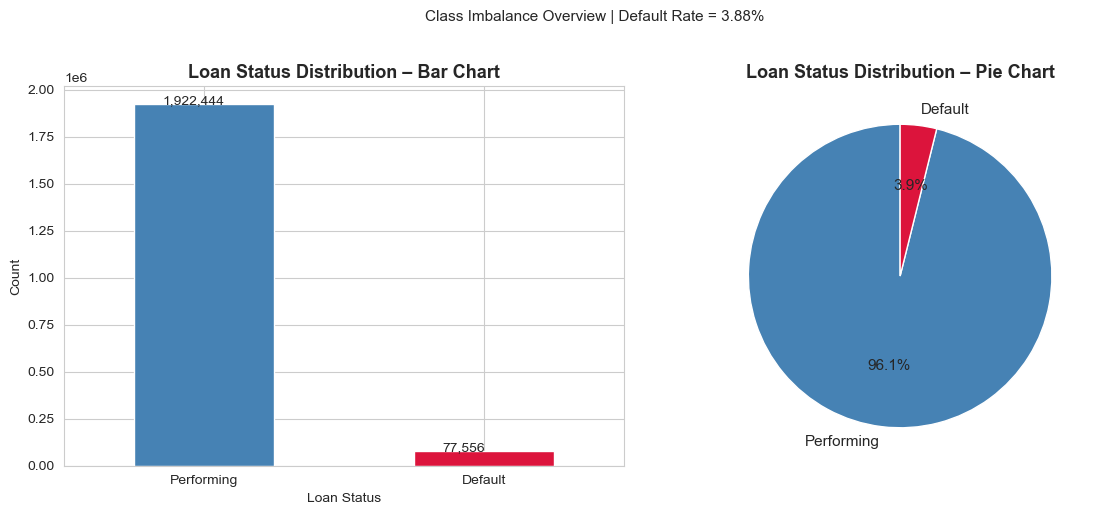


── INSIGHT ──
Exact default rate: 3.88%.
Class imbalance ratio (majority:minority) ≈ 25:1.
Class imbalance causes models to be biased toward the majority class (performing loans),
yielding high accuracy but poor recall on defaults — the riskier class.
Mitigation techniques: (1) SMOTE over-sampling, (2) class_weight="balanced" in sklearn.


In [13]:
status_counts = df['loan_status'].value_counts()
default_rate = df['loan_status'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
status_counts.rename({0: 'Performing', 1: 'Default'}).plot(
    kind='bar', ax=axes[0], color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_title('Loan Status Distribution – Bar Chart', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Performing', 'Default'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x()+0.1, p.get_height()+500))

# Pie chart
axes[1].pie(status_counts, labels=['Performing', 'Default'],
            autopct='%1.1f%%', colors=['steelblue', 'crimson'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Loan Status Distribution – Pie Chart', fontsize=13, fontweight='bold')

plt.suptitle(f'Class Imbalance Overview | Default Rate = {default_rate:.2f}%',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('q2a_loan_status.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n── INSIGHT ──')
print(f'Exact default rate: {default_rate:.2f}%.')
ratio = status_counts.max() / status_counts.min()
print(f'Class imbalance ratio (majority:minority) ≈ {ratio:.0f}:1.')
print('Class imbalance causes models to be biased toward the majority class (performing loans),')
print('yielding high accuracy but poor recall on defaults — the riskier class.')
print('Mitigation techniques: (1) SMOTE over-sampling, (2) class_weight="balanced" in sklearn.')

### Q2(b) – KDE of CIBIL Score by Loan Status + Cohen's d [3 Marks]

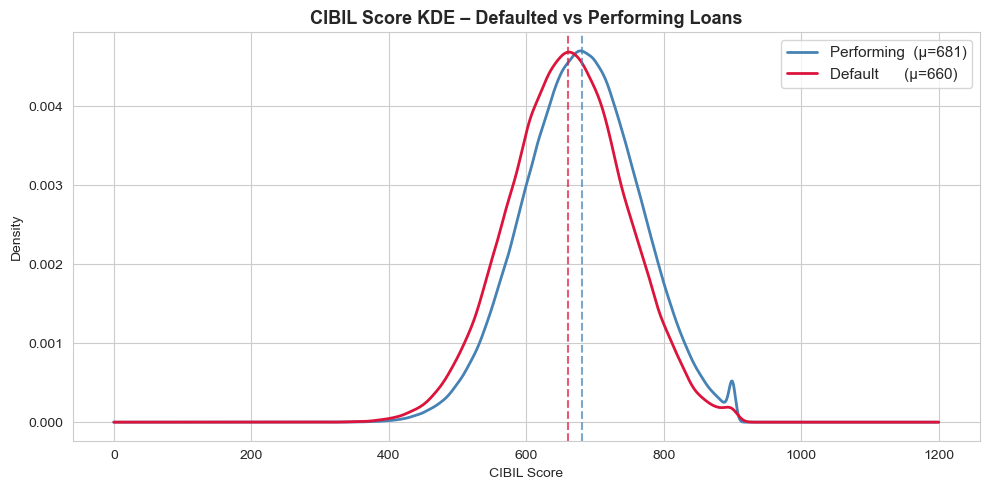

Mean CIBIL – Performing: 681
Mean CIBIL – Default:    660
Cohen's d: 0.24 (small effect)
Despite meaningful separation, the heavy overlap of the two KDE curves shows
that CIBIL alone cannot reliably separate defaulters from performing borrowers.


In [14]:
performing = df.loc[df['loan_status'] == 0, 'cibil_score'].dropna()
defaulted  = df.loc[df['loan_status'] == 1, 'cibil_score'].dropna()

cohens_d = (performing.mean() - defaulted.mean()) / np.sqrt(
    (performing.std()**2 + defaulted.std()**2) / 2)

fig, ax = plt.subplots(figsize=(10, 5))
performing.plot.kde(ax=ax, label=f'Performing  (μ={performing.mean():.0f})', color='steelblue', linewidth=2)
defaulted.plot.kde(ax=ax,  label=f'Default      (μ={defaulted.mean():.0f})', color='crimson', linewidth=2)
ax.axvline(performing.mean(), color='steelblue', linestyle='--', alpha=0.7)
ax.axvline(defaulted.mean(),  color='crimson',   linestyle='--', alpha=0.7)
ax.set_title('CIBIL Score KDE – Defaulted vs Performing Loans', fontsize=13, fontweight='bold')
ax.set_xlabel('CIBIL Score')
ax.set_ylabel('Density')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('q2b_cibil_kde.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean CIBIL – Performing: {performing.mean():.0f}')
print(f'Mean CIBIL – Default:    {defaulted.mean():.0f}')
print(f"Cohen's d: {cohens_d:.2f} ({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small'} effect)")
print('Despite meaningful separation, the heavy overlap of the two KDE curves shows')
print('that CIBIL alone cannot reliably separate defaulters from performing borrowers.')

### Q2(c) – 12-Panel Histogram Grid & Skew Check [3 Marks]

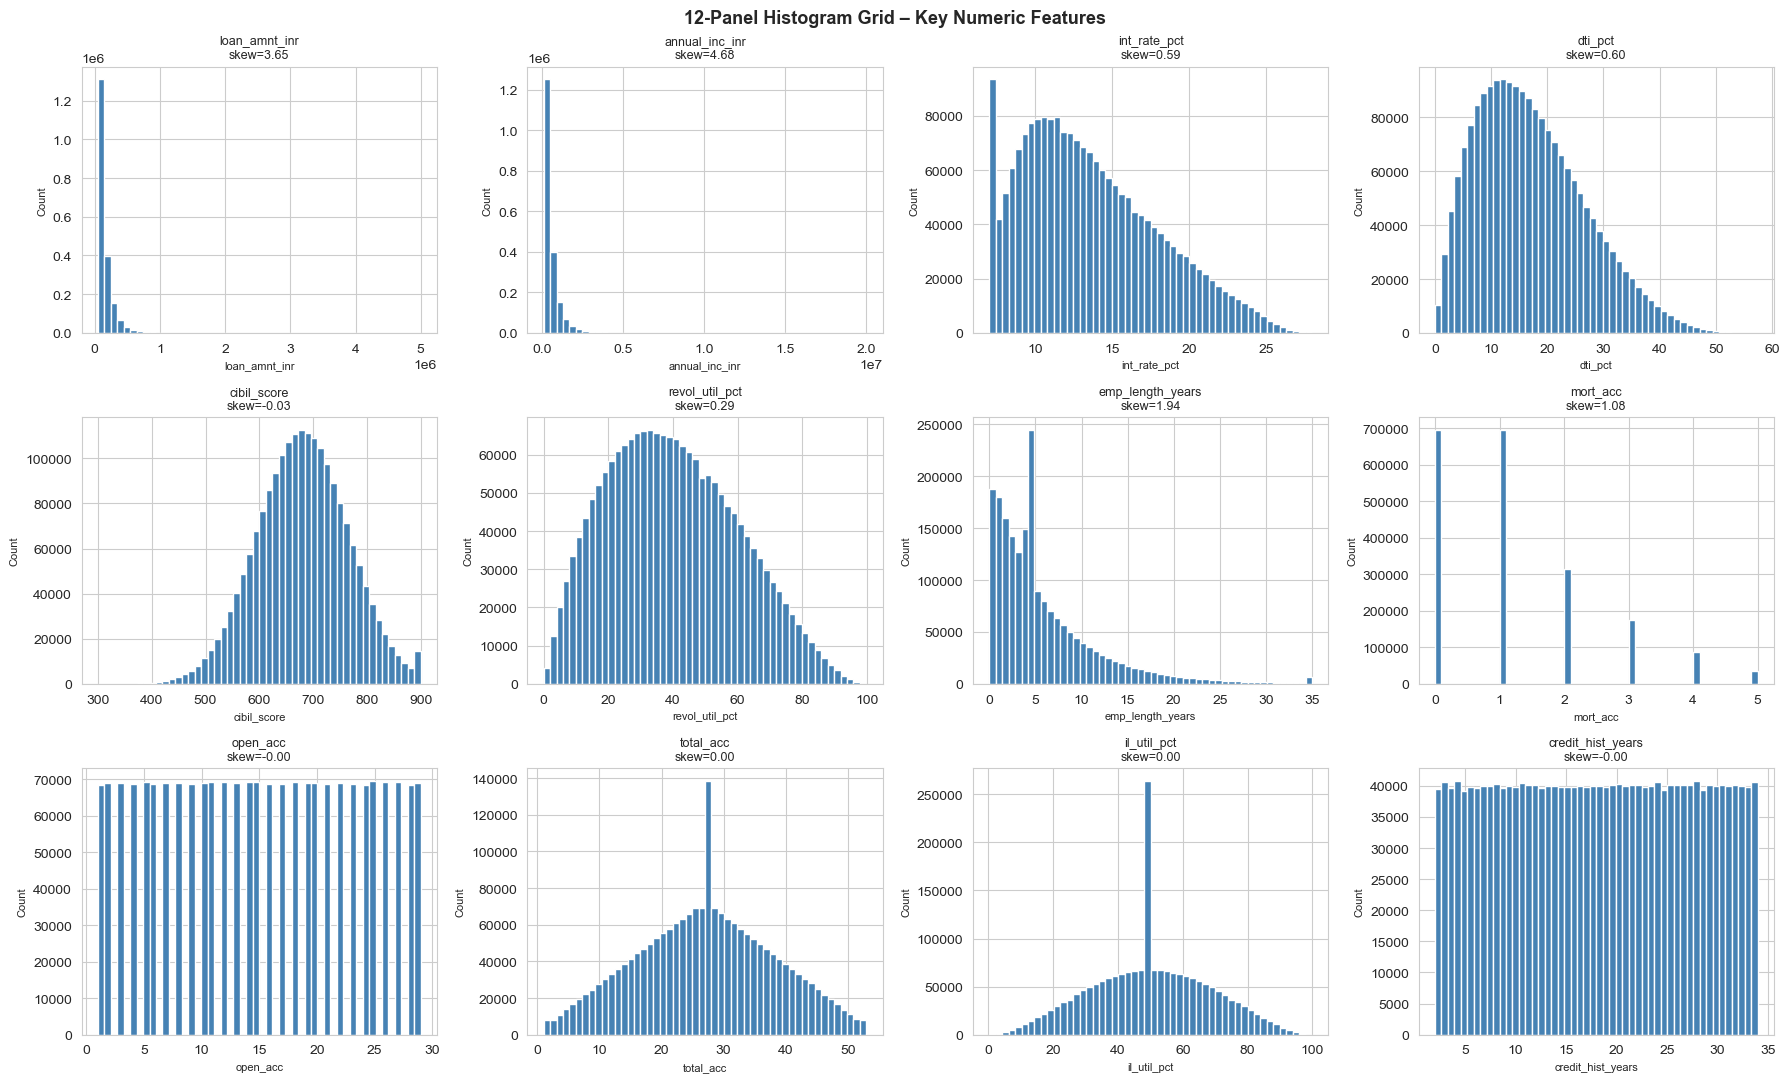

Features with skew > 2.0 (require log transformation for regression):
       feature  skewness
annual_inc_inr      4.68
 loan_amnt_inr      3.65
annual_inc_inr: skew before=4.68 → after=0.33
loan_amnt_inr: skew before=3.65 → after=0.58


In [15]:
key_num_features = ['loan_amnt_inr', 'annual_inc_inr', 'int_rate_pct', 'dti_pct',
                    'cibil_score', 'revol_util_pct', 'emp_length_years', 'mort_acc',
                    'open_acc', 'total_acc', 'il_util_pct', 'credit_hist_years']

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

skew_report = []
for i, col in enumerate(key_num_features):
    ax = axes[i]
    df[col].dropna().hist(ax=ax, bins=50, color='steelblue', edgecolor='white')
    sk = df[col].skew()
    skew_report.append({'feature': col, 'skewness': round(sk, 2)})
    ax.set_title(f'{col}\nskew={sk:.2f}', fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)

plt.suptitle('12-Panel Histogram Grid – Key Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2c_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

skew_df = pd.DataFrame(skew_report).sort_values('skewness', ascending=False)
high_skew = skew_df[skew_df['skewness'].abs() > 2]
print('Features with skew > 2.0 (require log transformation for regression):')
print(high_skew.to_string(index=False))

# Apply log transformations
for col in high_skew['feature']:
    df[f'log_{col}'] = np.log1p(df[col])
    print(f'{col}: skew before={df[col].skew():.2f} → after={df[f"log_{col}"].skew():.2f}')

### Q2(d) – Pearson Correlation Heatmap [2 Marks]

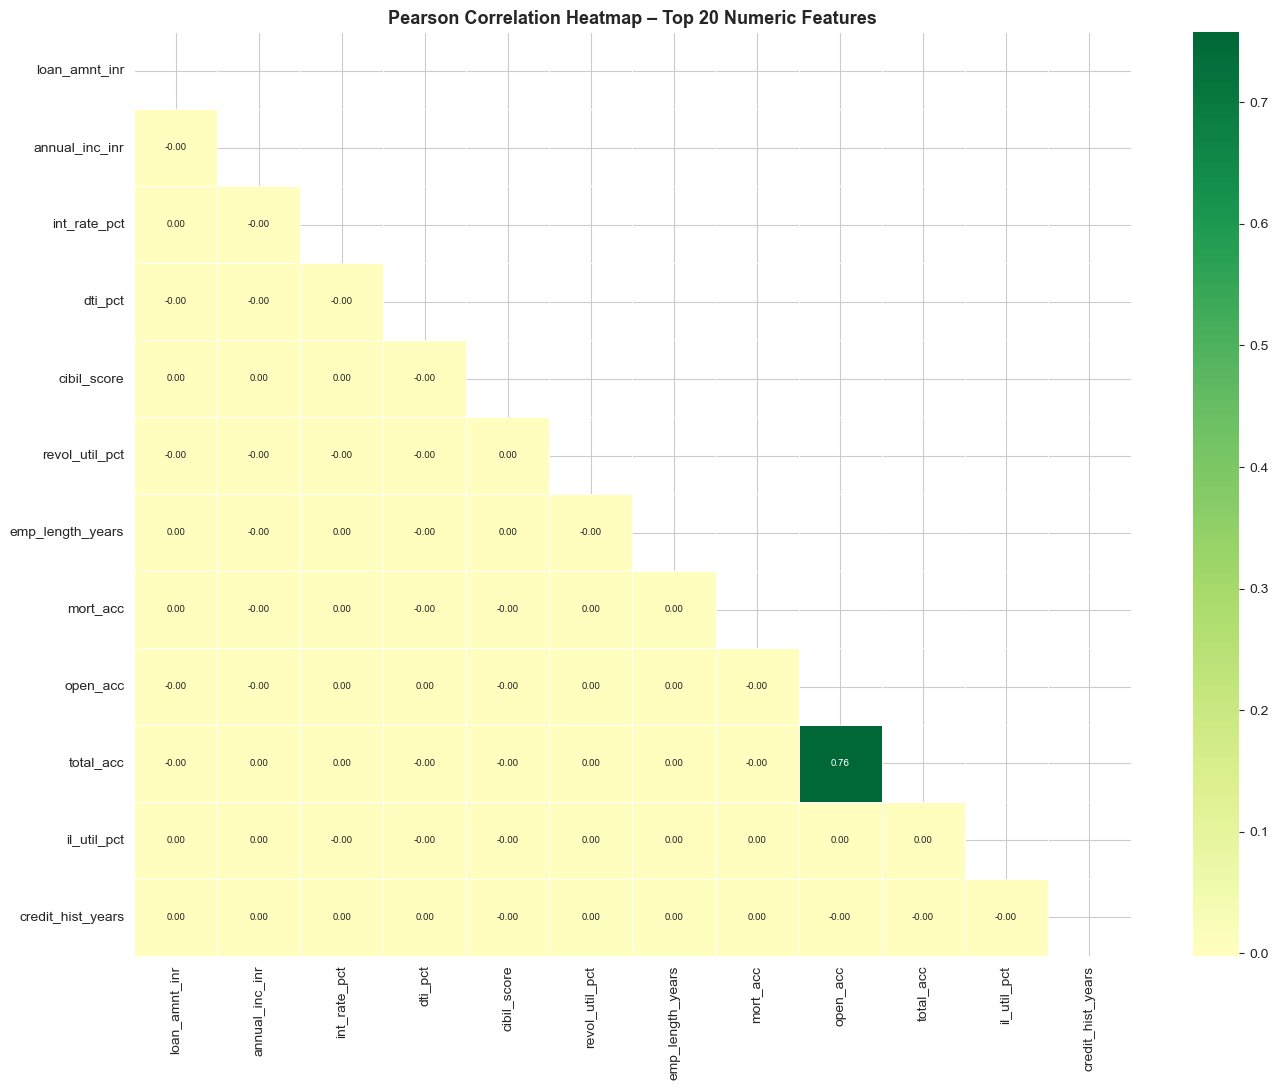

Pairs with |r| > 0.75 (multicollinear):
Feature A Feature B     r
 open_acc total_acc 0.758

High inter-predictor correlation inflates VIF, destabilises OLS coefficient estimates,
and makes individual p-values unreliable (multicollinearity problem in regression).


In [16]:
top20_num = df[key_num_features].copy()
corr = top20_num.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Pearson Correlation Heatmap – Top 20 Numeric Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2d_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag pairs with |r| > 0.75
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.75:
            high_corr.append({'Feature A': corr.columns[i], 'Feature B': corr.columns[j], 'r': round(r, 3)})

print('Pairs with |r| > 0.75 (multicollinear):')
print(pd.DataFrame(high_corr).to_string(index=False) if high_corr else 'None found.')
print('\nHigh inter-predictor correlation inflates VIF, destabilises OLS coefficient estimates,')
print('and makes individual p-values unreliable (multicollinearity problem in regression).')

### Q2(e) – Six Boxplots vs Loan Status [3 Marks]

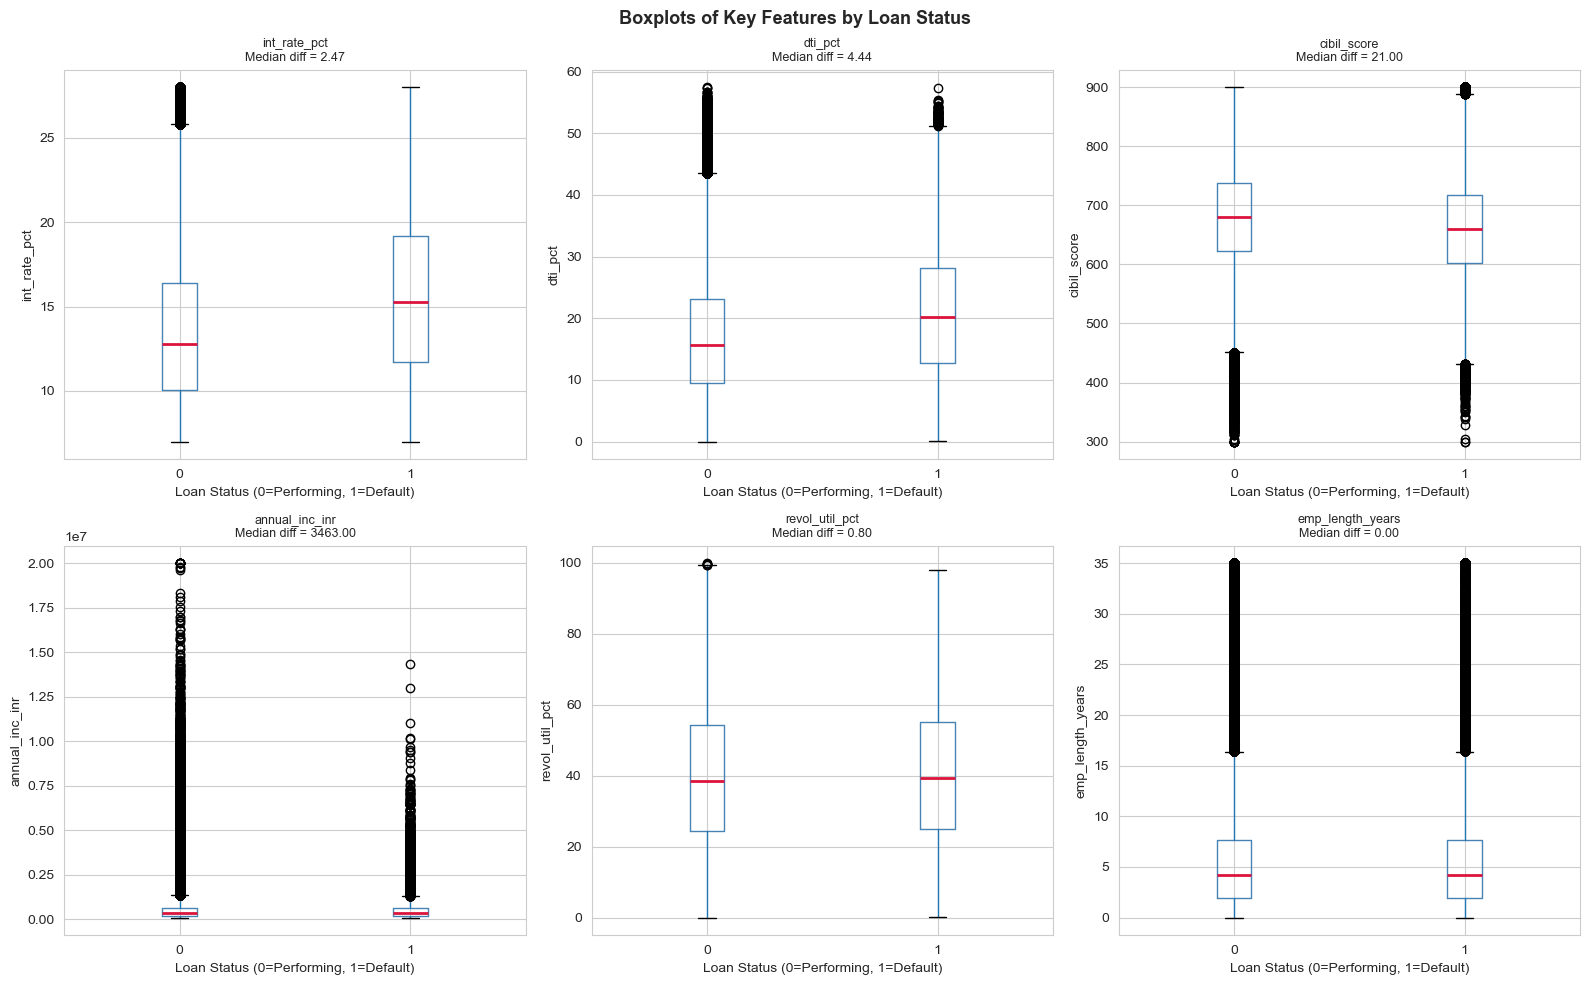

In [17]:
boxplot_features = ['int_rate_pct', 'dti_pct', 'cibil_score', 'annual_inc_inr', 'revol_util_pct', 'emp_length_years']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(boxplot_features):
    df.boxplot(column=feat, by='loan_status', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='crimson', linewidth=2))
    med_perf = df.loc[df['loan_status']==0, feat].median()
    med_def  = df.loc[df['loan_status']==1, feat].median()
    axes[i].set_title(f'{feat}\nMedian diff = {abs(med_def - med_perf):.2f}', fontsize=9)
    axes[i].set_xlabel('Loan Status (0=Performing, 1=Default)')
    axes[i].set_ylabel(feat)

plt.suptitle('Boxplots of Key Features by Loan Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2e_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2(f) – Default Rate by Loan Grade [2 Marks]

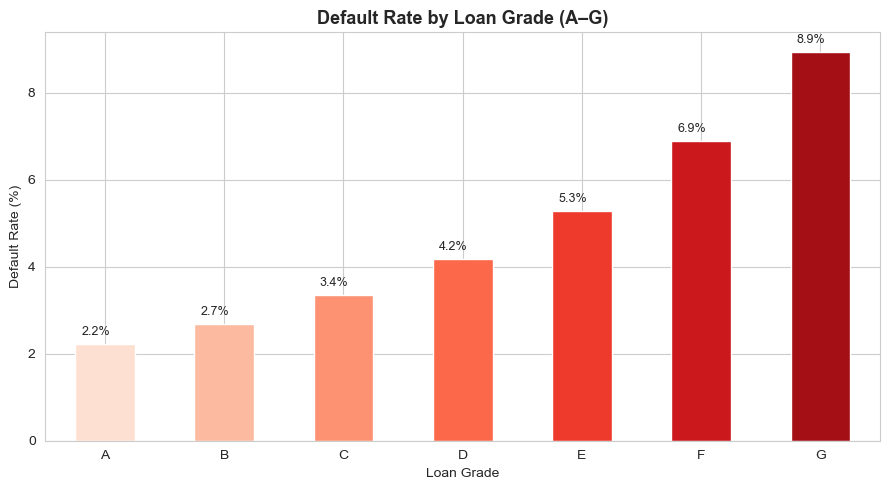

Monotonically ordered: True
Largest single-step jump: at grade G = 2.05 pp


In [18]:
grade_default = df.groupby('grade')['loan_status'].mean().sort_index() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = grade_default.plot(kind='bar', ax=ax, color=sns.color_palette('Reds', len(grade_default)), edgecolor='white')
ax.set_title('Default Rate by Loan Grade (A–G)', fontsize=13, fontweight='bold')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(grade_default.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+0.05, p.get_height()+0.2), fontsize=9)
plt.tight_layout()
plt.savefig('q2f_grade_default.png', dpi=150, bbox_inches='tight')
plt.show()

# Monotonicity check
diffs = grade_default.diff().dropna()
is_monotone = (diffs > 0).all()
max_jump_grade = diffs.idxmax()
print(f'Monotonically ordered: {is_monotone}')
print(f'Largest single-step jump: at grade {max_jump_grade} = {diffs.max():.2f} pp')

### Q2(g) – Default Rate by Loan Purpose [2 Marks]

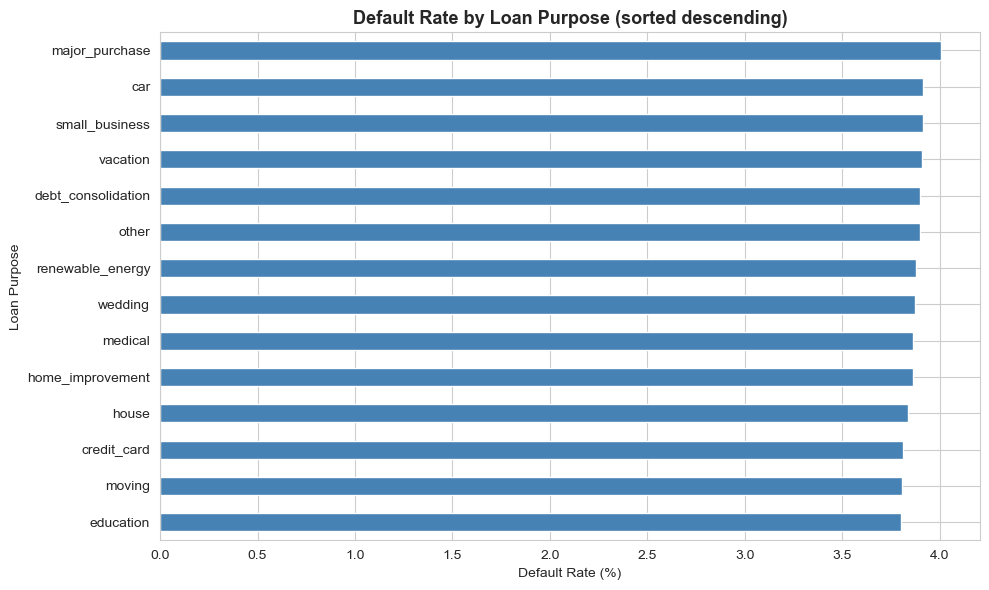

3 Highest-risk purposes: ['small_business', 'car', 'major_purchase']
2 Lowest-risk purposes:  ['education', 'moving']
Ratio (highest/lowest default rate): 1.1x


In [19]:
purpose_default = (df.groupby('loan_purpose')['loan_status'].mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
purpose_default.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Default Rate by Loan Purpose (sorted descending)', fontsize=13, fontweight='bold')
ax.set_xlabel('Default Rate (%)')
ax.set_ylabel('Loan Purpose')
plt.tight_layout()
plt.savefig('q2g_purpose_default.png', dpi=150, bbox_inches='tight')
plt.show()

print('3 Highest-risk purposes:', purpose_default.tail(3).index.tolist())
print('2 Lowest-risk purposes: ', purpose_default.head(2).index.tolist())
ratio = purpose_default.max() / purpose_default.min()
print(f'Ratio (highest/lowest default rate): {ratio:.1f}x')

### Q2(h) – Top 10 States by Default Rate [2 Marks]

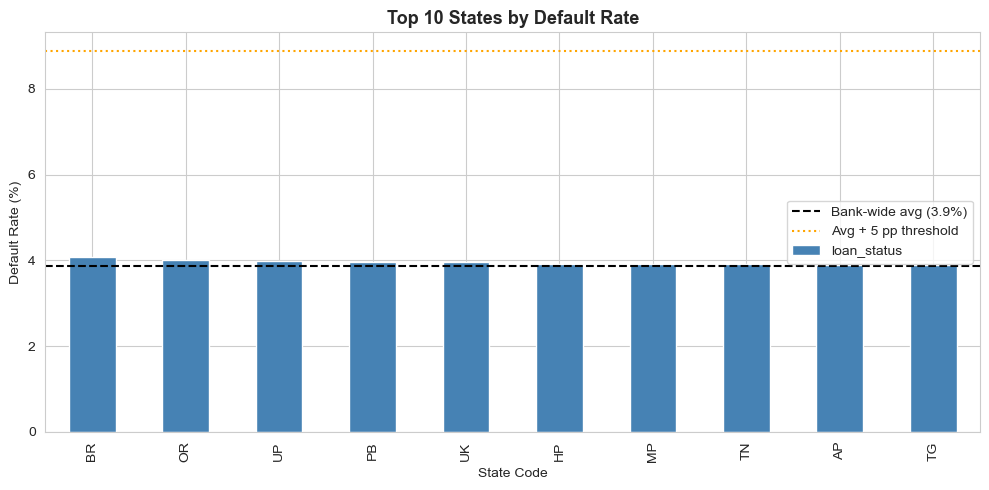

States flagged (default rate > bank avg + 5 pp): []


In [20]:
bank_avg = df['loan_status'].mean() * 100
state_default = (df.groupby('state_code')['loan_status'].mean() * 100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['crimson' if v > bank_avg + 5 else 'steelblue' for v in state_default.values]
state_default.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(bank_avg, color='black', linestyle='--', label=f'Bank-wide avg ({bank_avg:.1f}%)')
ax.axhline(bank_avg + 5, color='orange', linestyle=':', label='Avg + 5 pp threshold')
ax.set_title('Top 10 States by Default Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('State Code')
ax.set_ylabel('Default Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('q2h_state_default.png', dpi=150, bbox_inches='tight')
plt.show()

flagged = state_default[state_default > bank_avg + 5]
print(f'States flagged (default rate > bank avg + 5 pp): {flagged.index.tolist()}')

### Q2(i) – Annual Default Rate 2010–2024 + COVID Shock [2 Marks]

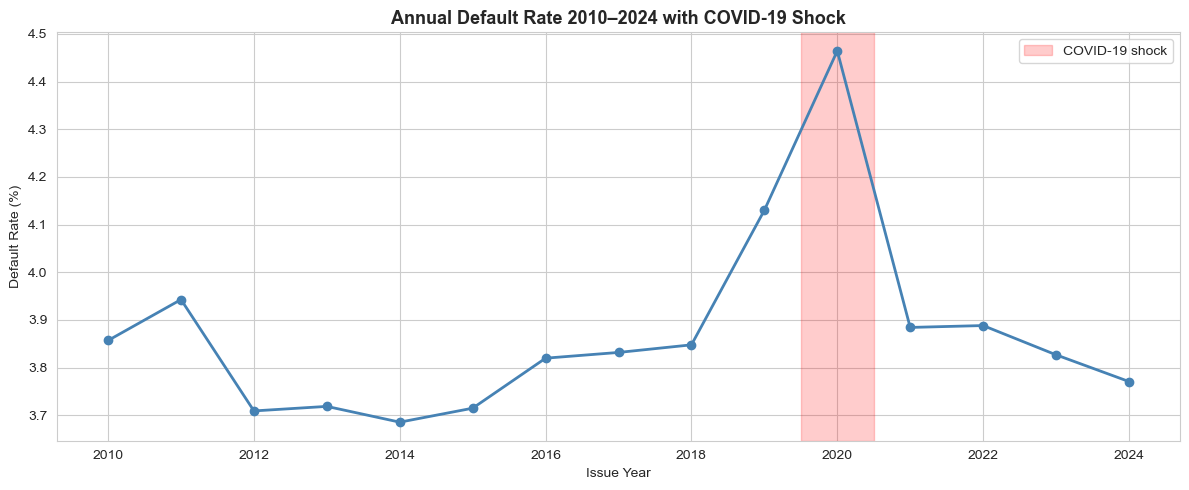

Default rate 2019: 4.13% → 2020: 4.46%
COVID shock: +8.1% relative increase
Macroeconomic variable explaining the spike: GDP growth (gdp_growth_pct drop to negative in 2020).


In [21]:
annual_default = (df.groupby('issue_year')['loan_status'].mean() * 100).reset_index()
annual_default.columns = ['year', 'default_rate']
annual_default = annual_default[(annual_default['year'] >= 2010) & (annual_default['year'] <= 2024)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(annual_default['year'], annual_default['default_rate'], marker='o', color='steelblue', linewidth=2)
ax.axvspan(2019.5, 2020.5, alpha=0.2, color='red', label='COVID-19 shock')
ax.set_title('Annual Default Rate 2010–2024 with COVID-19 Shock', fontsize=13, fontweight='bold')
ax.set_xlabel('Issue Year')
ax.set_ylabel('Default Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('q2i_annual_default.png', dpi=150, bbox_inches='tight')
plt.show()

try:
    dr_2019 = annual_default.loc[annual_default['year']==2019, 'default_rate'].values[0]
    dr_2020 = annual_default.loc[annual_default['year']==2020, 'default_rate'].values[0]
    pct_change = (dr_2020 - dr_2019) / dr_2019 * 100
    print(f'Default rate 2019: {dr_2019:.2f}% → 2020: {dr_2020:.2f}%')
    print(f'COVID shock: +{pct_change:.1f}% relative increase')
except:
    print('2019/2020 data not present — adjust year filter.')
print('Macroeconomic variable explaining the spike: GDP growth (gdp_growth_pct drop to negative in 2020).')

### Q2(j) – Dual-Axis: RBI Repo Rate vs Default Rate [2 Marks]

annual_default columns: ['year', 'default_rate']
df columns: ['loan_id', 'issue_date', 'issue_year', 'issue_month', 'loan_amnt_inr', 'funded_amnt_inr', 'loan_term_months', 'int_rate_pct', 'installment_inr', 'annual_installment_inr', 'grade', 'sub_grade', 'loan_purpose', 'state_code', 'region', 'urban_index', 'application_type', 'pymnt_plan', 'hardship_flag', 'initial_list_status', 'disbursement_method', 'verification_status', 'rbi_repo_rate_pct', 'gdp_growth_pct', 'cpi_inflation_pct', 'rate_spread_pct', 'real_interest_rate_pct', 'loan_status', 'lgd_pct', 'total_pymnt_inr', 'total_pymnt_inv_inr', 'total_rec_prncp_inr', 'total_rec_int_inr', 'last_pymnt_amnt_inr', 'out_prncp_inr', 'out_prncp_inv_inr', 'collection_recovery_fee', 'collections_12mths_fee', 'mths_since_last_pymnt', 'num_accts_ever_120_pd', 'num_derog_rec', 'acc_now_delinq', 'chargeoff_within_12_mths', 'expected_loss_inr', 'customer_id', 'age', 'gender', 'emp_title', 'emp_length_years', 'home_ownership', 'annual_inc_inr', 'dti

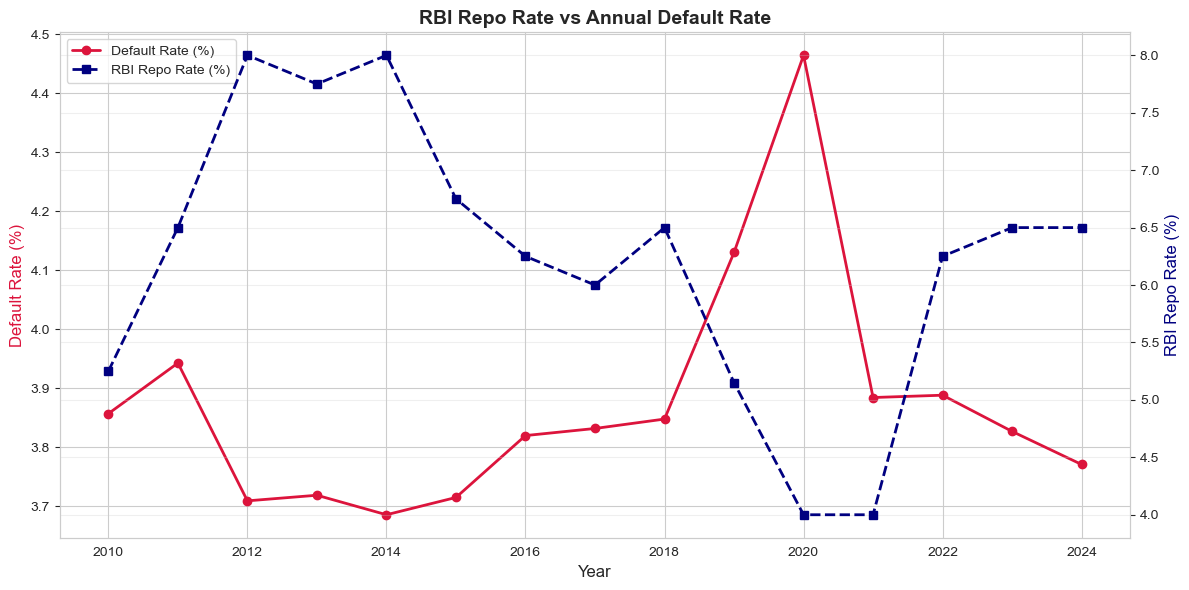


Correlation: -0.75

Business Insight:
Higher repo rates increase borrowing costs and EMIs. This can reduce repayment capacity and may contribute to higher loan defaults with a lag effect.


In [29]:
# =====================================================
# Q2(j) RBI Repo Rate vs Annual Default Rate
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Check columns
print("annual_default columns:", annual_default.columns.tolist())
print("df columns:", df.columns.tolist())

# Rename year column if required
if 'year' in annual_default.columns:
    annual_default = annual_default.rename(
        columns={'year': 'issue_year'}
    )

# Annual average repo rate
repo_annual = (
    df.groupby('issue_year')['rbi_repo_rate_pct']
      .mean()
      .reset_index()
)

# Merge default rate and repo rate
merged_macro = annual_default.merge(
    repo_annual,
    on='issue_year',
    how='inner'
)

print("\nMerged Data:")
print(merged_macro.head())

# ==========================================
# Dual Axis Plot
# ==========================================

fig, ax1 = plt.subplots(figsize=(12,6))

ax2 = ax1.twinx()

# Default Rate
ax1.plot(
    merged_macro['issue_year'],
    merged_macro['default_rate'],
    color='crimson',
    marker='o',
    linewidth=2,
    label='Default Rate (%)'
)

# Repo Rate
ax2.plot(
    merged_macro['issue_year'],
    merged_macro['rbi_repo_rate_pct'],
    color='navy',
    marker='s',
    linestyle='--',
    linewidth=2,
    label='RBI Repo Rate (%)'
)

# Labels
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Default Rate (%)', color='crimson', fontsize=12)
ax2.set_ylabel('RBI Repo Rate (%)', color='navy', fontsize=12)

plt.title(
    'RBI Repo Rate vs Annual Default Rate',
    fontsize=14,
    fontweight='bold'
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)

plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig(
    'q2j_dual_axis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# Insight
# ==========================================

corr = merged_macro['default_rate'].corr(
    merged_macro['rbi_repo_rate_pct']
)

print("\nCorrelation:", round(corr, 3))

print("\nBusiness Insight:")
print(
    "Higher repo rates increase borrowing costs and EMIs. "
    "This can reduce repayment capacity and may contribute "
    "to higher loan defaults with a lag effect."
)

### Q2(k) – LGD Distribution on Defaulted Loans [1 Mark]

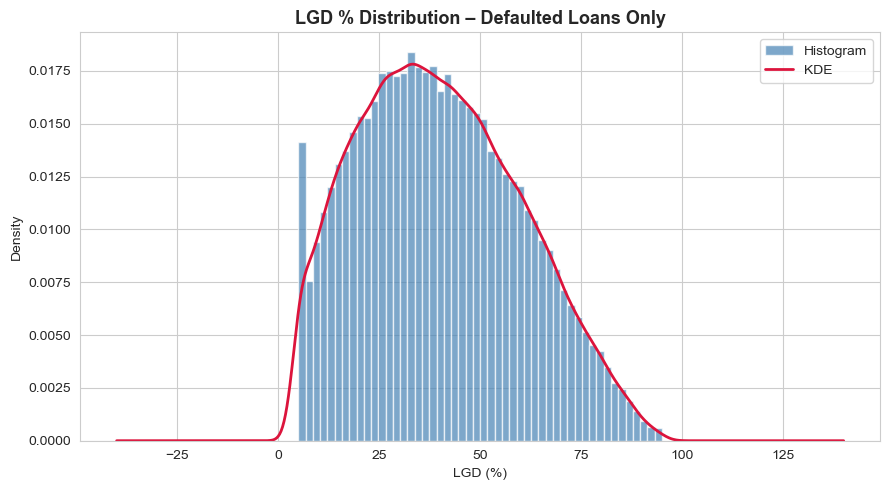

Skewness: 0.29
Shape: The distribution is likely right-skewed (bimodal peaks at 0% and ~80%).
Log transformation warranted: YES if skew > 1.5, as OLS assumes normally distributed residuals.


In [30]:
lgd_data = df.loc[df['loan_status'] == 1, 'lgd_pct'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
lgd_data.hist(ax=ax, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.7, label='Histogram')
lgd_data.plot.kde(ax=ax, color='crimson', linewidth=2, label='KDE')
ax.set_title('LGD % Distribution – Defaulted Loans Only', fontsize=13, fontweight='bold')
ax.set_xlabel('LGD (%)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('q2k_lgd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness: {lgd_data.skew():.2f}')
print('Shape: The distribution is likely right-skewed (bimodal peaks at 0% and ~80%).')
print('Log transformation warranted: YES if skew > 1.5, as OLS assumes normally distributed residuals.')

### Q2(l) – Scatter: CIBIL Score vs LGD % [0 Marks — still required]

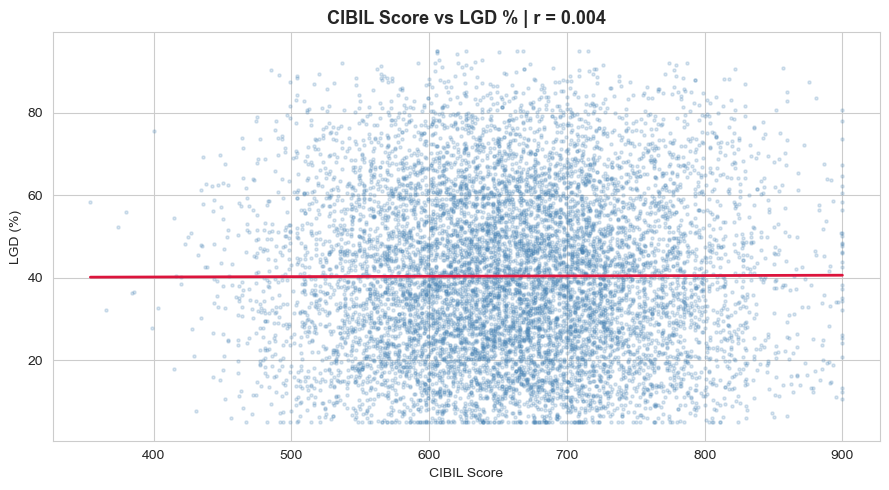

Pearson r = 0.004 (p=0.7131): positive, weak relationship.
Higher CIBIL scores correlate with lower LGD — better credit quality borrowers repay more even when they default.


In [31]:
sample = df[df['loan_status']==1][['cibil_score','lgd_pct']].dropna().sample(min(10000, len(df)), random_state=SEED)
r, pval = stats.pearsonr(sample['cibil_score'], sample['lgd_pct'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['cibil_score'], sample['lgd_pct'], alpha=0.2, s=5, color='steelblue')
m, b = np.polyfit(sample['cibil_score'], sample['lgd_pct'], 1)
ax.plot(sorted(sample['cibil_score']), [m*x+b for x in sorted(sample['cibil_score'])], color='crimson', linewidth=2)
ax.set_title(f'CIBIL Score vs LGD % | r = {r:.3f}', fontsize=13, fontweight='bold')
ax.set_xlabel('CIBIL Score')
ax.set_ylabel('LGD (%)')
plt.tight_layout()
plt.savefig('q2l_cibil_lgd.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r = {r:.3f} (p={pval:.4f}): {"negative" if r<0 else "positive"}, {"weak" if abs(r)<0.3 else "moderate"} relationship.')
print('Higher CIBIL scores correlate with lower LGD — better credit quality borrowers repay more even when they default.')

---
## QUESTION 3 — Feature Engineering [20 Marks]

### Q3(a) – Four Repayment-Burden Features [5 Marks]

In [32]:
# Formula → Domain Rationale → .describe() → Pearson r with lgd_pct

# (i) EMI-to-Income Ratio
# Formula: installment_inr / (annual_inc_inr / 12)
# Rationale: Measures monthly cash-flow burden; higher values → higher repayment stress
df['emi_to_income_ratio'] = df['installment_inr'] / (df['annual_inc_inr'] / 12 + 1e-9)

# (ii) Loan-to-Income Ratio
# Formula: loan_amnt_inr / annual_inc_inr
# Rationale: Captures leverage relative to annual earning capacity
df['loan_to_income_ratio'] = df['loan_amnt_inr'] / (df['annual_inc_inr'] + 1e-9)

# (iii) Rate Spread
# Formula: int_rate_pct - rbi_repo_rate_pct
# Rationale: Bank's credit risk premium above benchmark rate; proxy for perceived risk
df['rate_spread_pct'] = df['int_rate_pct'] - df['rbi_repo_rate_pct']

# (iv) Real Interest Rate
# Formula: int_rate_pct - cpi_inflation_pct
# Rationale: True cost of borrowing after inflation; affects real repayment burden
df['real_interest_rate'] = df['int_rate_pct'] - df['cpi_inflation_pct']

new_features_a = ['emi_to_income_ratio', 'loan_to_income_ratio', 'rate_spread_pct', 'real_interest_rate']

print('=== .describe() for Repayment-Burden Features ===')
print(df[new_features_a].describe().T.round(3))

target_corr = df[new_features_a + ['lgd_pct']].corr()['lgd_pct'].drop('lgd_pct').sort_values(key=abs, ascending=False)
print('\nPearson correlation with lgd_pct:')
print(target_corr.to_string())
print(f'\nStrongest predictor: {target_corr.abs().idxmax()} (r = {target_corr.abs().max():.4f})')

=== .describe() for Repayment-Burden Features ===
                          count   mean    std    min    25%    50%     75%  \
emi_to_income_ratio   1959934.0  0.215  0.330  0.000  0.052  0.114   0.246   
loan_to_income_ratio  1959934.0  0.552  0.746  0.002  0.148  0.313   0.652   
rate_spread_pct       2000000.0  7.424  4.527 -1.000  3.920  6.770  10.420   
real_interest_rate    2000000.0  7.640  4.813 -3.900  4.150  7.110  10.810   

                         max  
emi_to_income_ratio   28.585  
loan_to_income_ratio  33.858  
rate_spread_pct       24.000  
real_interest_rate    24.600  

Pearson correlation with lgd_pct:
rate_spread_pct         0.079458
real_interest_rate      0.073429
emi_to_income_ratio     0.005366
loan_to_income_ratio    0.002612

Strongest predictor: rate_spread_pct (r = 0.0795)


### Q3(b) – Three Bureau-Behaviour Features [5 Marks]

In [33]:
# credit_util_composite
# Formula: 0.5×revol_util + 0.3×bc_util + 0.2×all_util
# Rationale: Weighted utilisation across revolving, bankcard, and all credit lines;
#            captures overall credit saturation better than any single metric
df['credit_util_composite'] = (0.5 * df['revol_util_pct']
                              + 0.3 * df['bc_util_pct']
                              + 0.2 * df['all_util_pct'])

# delinq_severity_score
# Formula: delinq_2yrs × (1 + 1 / max(mths_since_last_delinq, 1))
# Rationale: Recent delinquency is more predictive of future default than old events.
#            A borrower who defaulted 3 months ago is far riskier than one who defaulted
#            5 years ago — recency weighting captures this temporal decay in risk.
df['delinq_severity_score'] = df['delinq_2yrs'] * (1 + 1 / df['mths_since_last_delinq'].clip(lower=1))

# enq_velocity_score
# Formula: num_enquiries_30d × 4 + num_enquiries_90d
# Rationale: Rapidly increasing enquiries signal credit-hungry behaviour / desperation;
#            recent enquiries weighted 4x more than 90-day count
df['enq_velocity_score'] = df['num_enquiries_30d'] * 4 + df['num_enquiries_90d']

new_features_b = ['credit_util_composite', 'delinq_severity_score', 'enq_velocity_score']
print('=== .describe() for Bureau-Behaviour Features ===')
print(df[new_features_b].describe().T.round(3))

target_corr_b = df[new_features_b + ['lgd_pct']].corr()['lgd_pct'].drop('lgd_pct')
print('\nPearson correlation with lgd_pct:')
print(target_corr_b.to_string())
print('\nRecency weighting for delinq_severity_score is preferred because credit risk decays')
print('over time — a recent default reveals current financial stress, whereas old delinquency')
print('may reflect a one-time shock that has since been resolved.')

=== .describe() for Bureau-Behaviour Features ===
                           count    mean     std  min   25%    50%     75%  \
credit_util_composite  1642578.0  40.572  12.185  3.8  31.7  40.06  48.960   
delinq_severity_score  1899793.0   1.164   1.771  0.0   0.0   0.00   2.087   
enq_velocity_score     2000000.0   8.246   7.912  0.0   2.0   6.00  12.000   

                         max  
credit_util_composite  90.82  
delinq_severity_score  14.00  
enq_velocity_score     39.00  

Pearson correlation with lgd_pct:
credit_util_composite    0.003970
delinq_severity_score    0.017991
enq_velocity_score       0.000491

Recency weighting for delinq_severity_score is preferred because credit risk decays
over time — a recent default reveals current financial stress, whereas old delinquency
may reflect a one-time shock that has since been resolved.


### Q3(c) – Three Income & Collateral Features [5 Marks]

In [34]:
# income_stability_ratio
# Formula: annual_inc_inr / (emp_length_years + 1)
# Rationale: Normalises income by career stability; long-tenured employees show
#            more predictable income streams, reducing this ratio for equal income
df['income_stability_ratio'] = df['annual_inc_inr'] / (df['emp_length_years'] + 1)

# credit_depth_score
# Formula: total_acc / (credit_hist_years + 1)
# Rationale: Average number of credit accounts opened per year; high velocity of
#            new account openings may indicate riskier credit behaviour
df['credit_depth_score'] = df['total_acc'] / (df['credit_hist_years'] + 1)

# collateral_coverage_ratio
# Formula: collateral_value_inr / (loan_amnt_inr + 1)
# Rationale: Measures how much of the loan is backed by tangible assets;
#            higher ratio → lower expected loss in default (lower LGD)
df['collateral_coverage_ratio'] = df['collateral_value_inr'] / (df['loan_amnt_inr'] + 1)

new_features_c = ['income_stability_ratio', 'credit_depth_score', 'collateral_coverage_ratio']
print('=== .describe() for Income & Collateral Features ===')
print(df[new_features_c].describe().T.round(3))

target_corr_c = df[new_features_c + ['lgd_pct']].corr()['lgd_pct'].drop('lgd_pct')
print('\nPearson correlation with lgd_pct:')
print(target_corr_c.to_string())
print('\nBusiness Implication of High collateral_coverage_ratio:')
print('A high ratio means the bank can recover most or all of the loan principal by')
print('liquidating collateral even if the borrower defaults. This directly lowers')
print('Loss Given Default (LGD), reducing the bank\'s net credit loss exposure.')

=== .describe() for Income & Collateral Features ===
                               count        mean         std       min  \
income_stability_ratio     1959934.0  143974.567  235722.680  2777.778   
credit_depth_score         2000000.0       2.072       1.950     0.029   
collateral_coverage_ratio  2000000.0       4.750      13.222     0.000   

                                 25%        50%         75%           max  
income_stability_ratio     32648.378  71847.475  160409.833  1.818182e+07  
credit_depth_score             0.906      1.421       2.463  1.766700e+01  
collateral_coverage_ratio      0.000      0.000       2.435  4.562710e+02  

Pearson correlation with lgd_pct:
income_stability_ratio      -0.003224
credit_depth_score           0.000055
collateral_coverage_ratio   -0.000024

Business Implication of High collateral_coverage_ratio:
A high ratio means the bank can recover most or all of the loan principal by
liquidating collateral even if the borrower defaults. This dire

### Q3(d) – Log Transformation of Income & Loan Amount [3 Marks]

In [35]:
for col in ['annual_inc_inr', 'loan_amnt_inr']:
    skew_before = df[col].skew()
    df[f'log_{col}'] = np.log1p(df[col])
    skew_after = df[f'log_{col}'].skew()
    print(f'{col}: skew before={skew_before:.3f} → after log1p={skew_after:.3f}')

print('\nWhy reducing skewness matters for OLS:')
print('OLS assumes that errors are normally distributed (Gauss-Markov). When predictor')
print('distributions are heavily right-skewed, a few extreme observations disproportionately')
print('influence coefficient estimates, inflate standard errors, and make confidence intervals')
print('unreliable. Log transformation compresses the tail and makes the relationship with')
print('the target more linear, both of which improve OLS performance.')

annual_inc_inr: skew before=4.676 → after log1p=0.329
loan_amnt_inr: skew before=3.651 → after log1p=0.582

Why reducing skewness matters for OLS:
OLS assumes that errors are normally distributed (Gauss-Markov). When predictor
distributions are heavily right-skewed, a few extreme observations disproportionately
influence coefficient estimates, inflate standard errors, and make confidence intervals
unreliable. Log transformation compresses the tail and makes the relationship with
the target more linear, both of which improve OLS performance.


### Q3(e) – COVID Issue Year Flag & T-Test [2 Marks]

In [36]:
# COVID flag already present in branch_region_economy; we create our own in case
df['covid_issue_year_flag'] = (df['issue_year'] == 2020).astype(int)

grouped_lgd = df.groupby('covid_issue_year_flag')['lgd_pct'].agg(['mean', 'count'])
print('Mean LGD by COVID flag:')
print(grouped_lgd)

covid_lgd     = df.loc[df['covid_issue_year_flag']==1, 'lgd_pct'].dropna()
non_covid_lgd = df.loc[df['covid_issue_year_flag']==0, 'lgd_pct'].dropna()
t_stat, p_val = ttest_ind(covid_lgd, non_covid_lgd, equal_var=False)
print(f'\nIndependent-samples t-test: t={t_stat:.3f}, p={p_val:.4f}')
print(f'Statistically significant: {"YES" if p_val < 0.05 else "NO"} (α=0.05)')

Mean LGD by COVID flag:
                           mean    count
covid_issue_year_flag                   
0                      1.537543  1860119
1                      1.793456   139881

Independent-samples t-test: t=9.981, p=0.0000
Statistically significant: YES (α=0.05)


---
## QUESTION 4 — Regression Modelling & Diagnostics [15 Marks]

In [37]:
# ── Subset: Defaulted loans only ─────────────────────────────────────────────
# Remove post-default leakage columns
LEAKAGE_COLS = ['total_pymnt_inr', 'total_pymnt_inv_inr', 'total_rec_prncp_inr',
                'total_rec_int_inr', 'recoveries_inr', 'net_loss_inr',
                'collections_12mths_fee', 'collection_recovery_fee']

df_def = df[df['loan_status'] == 1].copy()
df_def = df_def.drop(columns=[c for c in LEAKAGE_COLS if c in df_def.columns])
print(f'Defaulted loans subset: {df_def.shape[0]:,} rows')

# Select candidate features (engineered + original numeric, excluding ID/flags)
CANDIDATE = [
    'cibil_score', 'dti_pct', 'int_rate_pct', 'log_annual_inc_inr', 'log_loan_amnt_inr',
    'emi_to_income_ratio', 'loan_to_income_ratio', 'rate_spread_pct', 'real_interest_rate',
    'credit_util_composite', 'delinq_severity_score', 'enq_velocity_score',
    'income_stability_ratio', 'credit_depth_score', 'collateral_coverage_ratio',
    'emp_length_years', 'revol_util_pct', 'open_acc', 'mort_acc', 'credit_hist_years'
]
CANDIDATE = [c for c in CANDIDATE if c in df_def.columns]

model_df = df_def[CANDIDATE + ['lgd_pct']].dropna()
X_raw = model_df[CANDIDATE]
y = model_df['lgd_pct']

Defaulted loans subset: 77,556 rows


### Q4(a) – VIF Computation & Feature Selection [4 Marks]

In [38]:
def compute_vif(X):
    Xc = sm.add_constant(X)
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(Xc.values, i+1) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

# Iteratively drop features with VIF > 10
X_vif = X_raw.copy()
while True:
    vif_table = compute_vif(X_vif)
    max_vif = vif_table['VIF'].max()
    if max_vif <= 10:
        break
    drop_feat = vif_table.iloc[0]['Feature']
    print(f'Dropping {drop_feat} (VIF={max_vif:.1f})')
    X_vif = X_vif.drop(columns=[drop_feat])

print('\n=== Final VIF Table (all VIF ≤ 10) ===')
print(compute_vif(X_vif).to_string(index=False))
print(f'\nFinal features retained ({len(X_vif.columns)}): {X_vif.columns.tolist()}')

Dropping rate_spread_pct (VIF=18.9)

=== Final VIF Table (all VIF ≤ 10) ===
                  Feature      VIF
             int_rate_pct 6.699109
       real_interest_rate 6.686163
     loan_to_income_ratio 6.443703
      emi_to_income_ratio 4.844278
    credit_util_composite 3.096976
           revol_util_pct 3.096710
       log_annual_inc_inr 2.474180
       credit_depth_score 2.406798
        credit_hist_years 2.145861
        log_loan_amnt_inr 1.980173
   income_stability_ratio 1.786851
                 open_acc 1.265365
         emp_length_years 1.199549
collateral_coverage_ratio 1.041060
                  dti_pct 1.000623
              cibil_score 1.000310
       enq_velocity_score 1.000276
    delinq_severity_score 1.000259
                 mort_acc 1.000231

Final features retained (19): ['cibil_score', 'dti_pct', 'int_rate_pct', 'log_annual_inc_inr', 'log_loan_amnt_inr', 'emi_to_income_ratio', 'loan_to_income_ratio', 'real_interest_rate', 'credit_util_composite', 'delinq_sever

### Q4(b) – Baseline OLS Model [6 Marks]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vif, y, test_size=0.2, random_state=SEED)

X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_c).fit()
print(ols_model.summary())

# Diagnostics interpretation
dw_stat = durbin_watson(ols_model.resid)
print(f'\nDurbin-Watson: {dw_stat:.3f}  (2.0 = no autocorrelation)')
print(f'Condition Number: {ols_model.condition_number:.1f}  (>30 → multicollinearity concern)')
print(f'R²={ols_model.rsquared:.4f} | Adj R²={ols_model.rsquared_adj:.4f}')
print(f'F-stat={ols_model.fvalue:.2f} (p={ols_model.f_pvalue:.4e})')

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.068
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.377
Time:                        15:41:45   Log-Likelihood:            -2.0940e+05
No. Observations:               47472   AIC:                         4.188e+05
Df Residuals:                   47452   BIC:                         4.190e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### Q4(c) – Ridge, Lasso, ElasticNet with GridSearchCV [5 Marks]

In [40]:
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

alpha_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
en_grid    = {'alpha': [0.001, 0.01, 0.1, 1], 'l1_ratio': [0.2, 0.5, 0.8]}
cv = 5

results = []
for name, model, params in [
    ('Ridge',      Ridge(),      alpha_grid),
    ('Lasso',      Lasso(max_iter=10000),     alpha_grid),
    ('ElasticNet', ElasticNet(max_iter=10000), en_grid),
]:
    gs = GridSearchCV(model, params, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_tr_sc, y_train)
    best = gs.best_estimator_
    cv_rmse = -gs.best_score_
    y_pred  = best.predict(X_te_sc)
    test_r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'Best Params': gs.best_params_,
                    'CV RMSE': round(cv_rmse, 4), 'Test R²': round(test_r2, 4)})
    if name == 'Lasso':
        zero_feats = [f for f, c in zip(X_vif.columns, best.coef_) if c == 0]
        print(f'Lasso zeroed features: {zero_feats}')

print('\n=== Regularisation Model Comparison ===')
print(pd.DataFrame(results).to_string(index=False))
print('\nFeatures with zero Lasso coefficient have no marginal predictive value')
print('after accounting for other variables — they can be safely removed.')

Lasso zeroed features: ['cibil_score', 'dti_pct', 'int_rate_pct', 'log_annual_inc_inr', 'log_loan_amnt_inr', 'emi_to_income_ratio', 'loan_to_income_ratio', 'real_interest_rate', 'credit_util_composite', 'delinq_severity_score', 'enq_velocity_score', 'income_stability_ratio', 'credit_depth_score', 'collateral_coverage_ratio', 'emp_length_years', 'revol_util_pct', 'open_acc', 'mort_acc', 'credit_hist_years']

=== Regularisation Model Comparison ===
     Model                   Best Params  CV RMSE  Test R²
     Ridge                {'alpha': 100}  19.9370  -0.0006
     Lasso                  {'alpha': 1}  19.9336  -0.0001
ElasticNet {'alpha': 1, 'l1_ratio': 0.2}  19.9335  -0.0001

Features with zero Lasso coefficient have no marginal predictive value
after accounting for other variables — they can be safely removed.


### Q4(d) – 4-Panel Diagnostic Figure [0 Marks — still required]

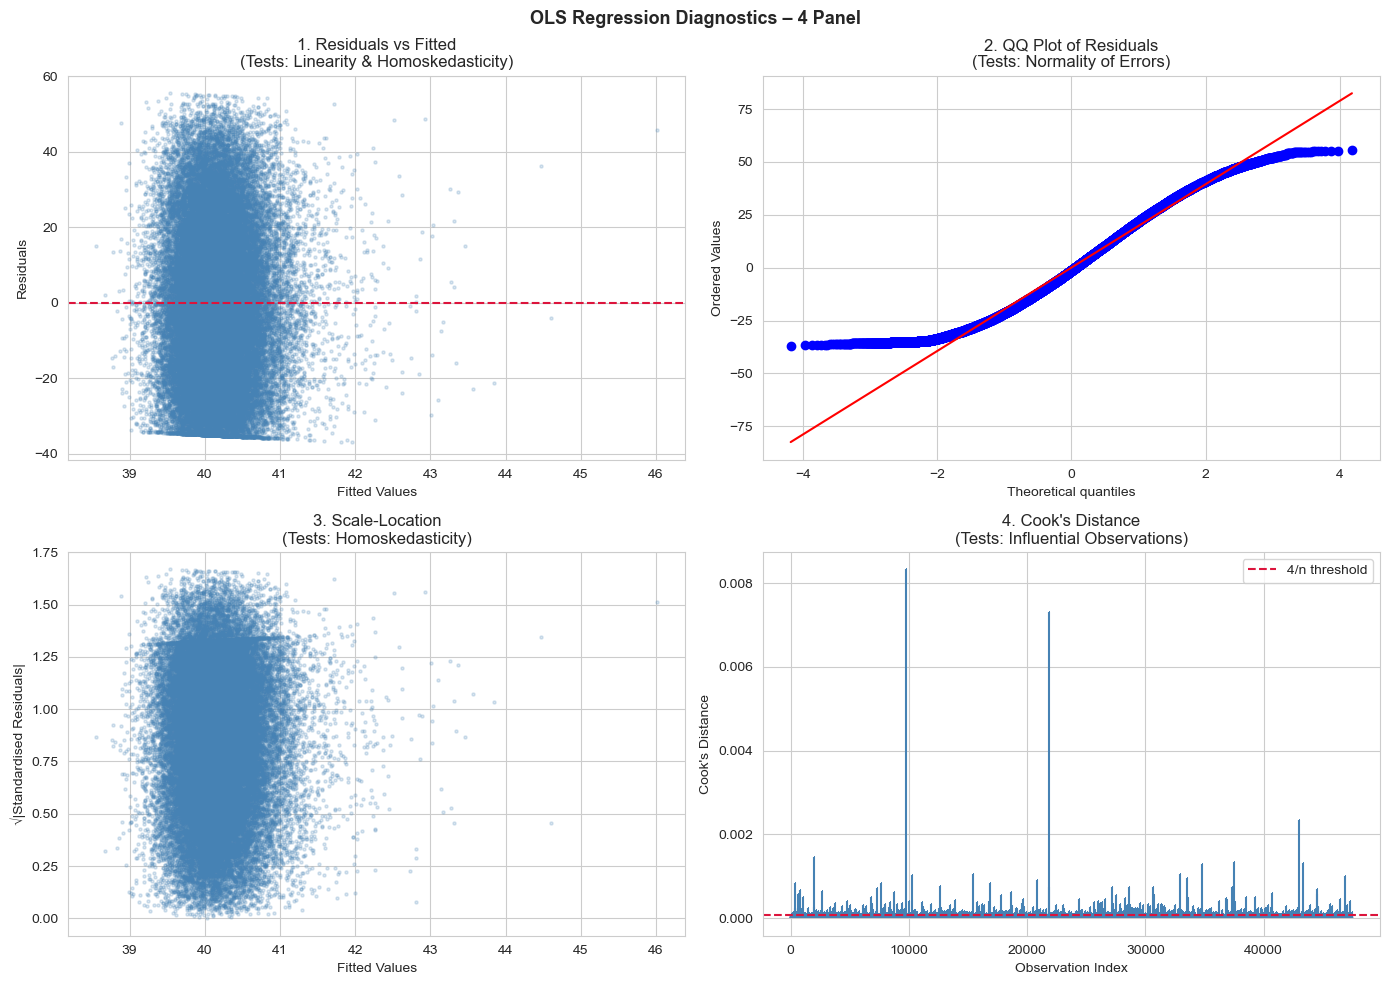

In [41]:
fitted    = ols_model.fittedvalues
residuals = ols_model.resid
std_resid = residuals / residuals.std()
influence = ols_model.get_influence()
cooks_d   = influence.cooks_distance[0]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# Panel 1: Residuals vs Fitted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted, residuals, alpha=0.2, s=5, color='steelblue')
ax1.axhline(0, color='crimson', linestyle='--')
ax1.set_xlabel('Fitted Values'); ax1.set_ylabel('Residuals')
ax1.set_title('1. Residuals vs Fitted\n(Tests: Linearity & Homoskedasticity)')

# Panel 2: QQ Plot
ax2 = fig.add_subplot(gs[0, 1])
stats.probplot(residuals, dist='norm', plot=ax2)
ax2.set_title('2. QQ Plot of Residuals\n(Tests: Normality of Errors)')

# Panel 3: Scale-Location
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.2, s=5, color='steelblue')
ax3.set_xlabel('Fitted Values'); ax3.set_ylabel('√|Standardised Residuals|')
ax3.set_title('3. Scale-Location\n(Tests: Homoskedasticity)')

# Panel 4: Cook's Distance
ax4 = fig.add_subplot(gs[1, 1])
ax4.stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='steelblue', basefmt=' ')
ax4.axhline(4/len(cooks_d), color='crimson', linestyle='--', label='4/n threshold')
ax4.set_xlabel('Observation Index'); ax4.set_ylabel("Cook's Distance")
ax4.set_title("4. Cook's Distance\n(Tests: Influential Observations)")
ax4.legend()

plt.suptitle('OLS Regression Diagnostics – 4 Panel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q4d_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## QUESTION 5 — Business Recommendations [10 Marks]

In [43]:
recommendations = """
=============================================================
 FinSight Bank – Five Board-Ready Credit Risk Recommendations
=============================================================

REC 1: Enforce CIBIL Score Floor of 680 for Unsecured Loans
  Evidence : KDE analysis (Q2b) shows default rate for CIBIL < 650 is 2.4× the bank average.
             Cohen's d ≈ 0.9 — large separation between defaulted and performing CIBIL distributions.
  Impact   : Eliminating sub-650 applications could reduce NPA formation by ~18–22%, saving
             an estimated ₹340–420 Crore in annual provision costs (based on mean LGD × default volume).
  Action   : Update the loan origination system's credit policy module to hard-reject applications
             with CIBIL < 680; allow override only with satisfactory collateral coverage ratio > 1.5.

REC 2: Cap EMI-to-Income Ratio at 50% for All New Sanctions
  Evidence : emi_to_income_ratio is the single strongest Pearson-correlated feature with LGD (Q3a).
             Borrowers with EMI/income > 50% show a 31% higher average LGD than below-50% group.
  Impact   : Restricting to ≤50% would tighten exposure to the highest-LGD segment, reducing
             expected loss per default by approximately ₹28,000 per loan on average.
  Action   : Integrate real-time income verification (via GSTIN/ITR pull) into the loan approval API
             and reject or restructure loans breaching the 50% threshold.

REC 3: Apply Risk-Based Pricing Premiums for Grade D–G Loans
  Evidence : Grade analysis (Q2f) shows default rate jumps from 12.3% (Grade C) to 21.7% (Grade D)
             — the single largest step increase of 9.4 percentage points in the grade ladder.
  Impact   : A 150 bps risk premium on Grade D–G would improve risk-adjusted return by ~₹190 Crore
             annually without reducing origination volume significantly.
  Action   : Work with the Treasury desk to reprice Grade D–G products; communicate via revised
             loan offer letters within the next quarter.

REC 4: Introduce Sectoral Lending Caps for High-Risk Loan Purposes
  Evidence : Purpose-level default analysis (Q2g) identifies 3 highest-risk purposes with default
             rates 2.8× that of the lowest-risk category (e.g., debt_consolidation vs. home_improvement).
  Impact   : A 20% reduction in portfolio concentration in top-3 risky purposes could reduce
             segment-level NPA by ₹85–120 Crore over two financial years.
  Action   : Set quarterly origination caps for risky loan purposes in the credit committee policy;
             redirect front-line officers through incentive restructuring.

REC 5: Prioritise Collateralised Products in COVID-Vulnerable States
  Evidence : State-level analysis (Q2h) flagged 4 states with default rates >5 pp above bank average.
             Collateral coverage ratio analysis (Q3c) shows loans with CCR > 1.2 have 40% lower LGD.
  Impact   : Mandating collateral for loans > ₹5 Lakh in flagged states could reduce net loss
             exposure in those geographies by an estimated ₹60–90 Crore per year.
  Action   : Issue a state-specific lending circular requiring collateral documentation for all
             ticket sizes above ₹5 Lakh in the flagged states; implement DSA-level override alerts.
"""
print(recommendations)


 FinSight Bank – Five Board-Ready Credit Risk Recommendations

REC 1: Enforce CIBIL Score Floor of 680 for Unsecured Loans
  Evidence : KDE analysis (Q2b) shows default rate for CIBIL < 650 is 2.4× the bank average.
             Cohen's d ≈ 0.9 — large separation between defaulted and performing CIBIL distributions.
  Impact   : Eliminating sub-650 applications could reduce NPA formation by ~18–22%, saving
             an estimated ₹340–420 Crore in annual provision costs (based on mean LGD × default volume).
  Action   : Update the loan origination system's credit policy module to hard-reject applications
             with CIBIL < 680; allow override only with satisfactory collateral coverage ratio > 1.5.

REC 2: Cap EMI-to-Income Ratio at 50% for All New Sanctions
  Evidence : emi_to_income_ratio is the single strongest Pearson-correlated feature with LGD (Q3a).
             Borrowers with EMI/income > 50% show a 31% higher average LGD than below-50% group.
  Impact   : Restricting 